# Private SpiderBoost on Criteo

End-to-end demo of Algorithm 2 from Arora et al. (ICML 2023, *Faster Rates of Convergence to Stationary Points in Differentially Private Optimization*) applied to CTR prediction on the 13 numerical Criteo features.

All training and plotting logic lives in the [src/](../src/) package. This notebook only configures, runs, and displays.

In [1]:
import sys, pathlib

# Locate the project root by walking up from cwd until we find src/datasets.py.
# Robust to renames and to launching Jupyter from any directory.
def _find_project():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'src' / 'datasets.py').is_file():
            return p
    raise RuntimeError(f'Could not locate project root (no src/datasets.py) from {here}')

PROJECT = _find_project()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))  # so 'src' is importable

from src.datasets import load_dataset
from src.privacy_accountant import compute_noise_scales, verify_epsilon
from src.train import TrainConfig, train, evaluate_auc
from src import visualization as viz
from src import model as model_mod
import numpy as np

In [2]:
DEVICE = 'cpu'  # 'cpu' or 'cuda' ('cuda' is an alias for JAX's 'gpu' backend)

from src.device import resolve_device
print(f'Using device: {resolve_device(DEVICE)}')

Using device: cpu:0


## Configuration

Single source of truth for hyperparameters. Edit and re-run the rest of the notebook to sweep.

In [3]:
DATA_PATH = PROJECT / 'data' / 'criteo_1M.parquet'
FIGS_DIR  = PROJECT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

config = TrainConfig(
    epsilon       = 1,
    delta         = 1 / (1.1 * 800000),
    L0            = 5.0,
    L1            = 5.0,
    T             = 1500,
    q             = 30,
    b1            = 8192,
    b2            = 512,
    eta           = 5e-3,
    hidden_dims   = (128, 64),
    seed          = 0,
    device        = DEVICE,
)
config

TrainConfig(epsilon=1, delta=1.1363636363636362e-06, L0=5.0, L1=5.0, T=1500, q=30, b1=8192, b2=512, eta=0.005, hidden_dims=(128, 64), seed=0, eval_every_steps=None, device='cpu', output_dim=1, eval_metric='auc')

In [4]:
data = load_dataset("criteo_1M", data_dir=DATA_PATH.parent, test_fraction=0.2, seed=config.seed)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')
print(f'positive rate (train): {float(data.y_train.mean()):.4f}')
print(f'positive rate (test):  {float(data.y_test.mean()):.4f}')

train: (800000, 13)   test: (200000, 13)
positive rate (train): 0.2510
positive rate (test):  0.2520


## 1. Load and preprocess Criteo (numerical features only)

In [5]:
data = load_dataset("criteo_1M", data_dir=DATA_PATH.parent, test_fraction=0.2, seed=config.seed, device=DEVICE)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')
print(f'positive rate (train): {float(data.y_train.mean()):.4f}')
print(f'positive rate (test):  {float(data.y_test.mean()):.4f}')

train: (800000, 13)   test: (200000, 13)
positive rate (train): 0.2510
positive rate (test):  0.2520


## 2. Compute noise scales (and sanity-check ε)

In [6]:
noise = compute_noise_scales(
    L0=config.L0, L1=config.L1,
    epsilon=config.epsilon, delta=config.delta,
    T=config.T, q=config.q, n=n_train,
    b1=config.b1, b2=config.b2,
)
print(f'sigma1     = {noise.sigma1:.4e}')
print(f'sigma2     = {noise.sigma2:.4e}')
print(f'sigma2_hat = {noise.sigma2_hat:.4e}')

eps_rdp = verify_epsilon(
    L0=config.L0, epsilon_target=config.epsilon, delta=config.delta,
    T=config.T, q=config.q, n=n_train,
    b1=config.b1, b2=config.b2,
    sigma1=noise.sigma1, sigma2_hat=noise.sigma2_hat,
)
print(f'\nRDP-accountant epsilon (sanity-check at delta={config.delta}): {eps_rdp:.4f}')
print(f'Target epsilon: {config.epsilon}')
print('Note: the RDP bound is loose; the algorithm uses tighter accounting (Theorem B.2).')

sigma1     = 2.2581e-03
sigma2     = 3.6130e-02
sigma2_hat = 7.2259e-02

RDP-accountant epsilon (sanity-check at delta=1.1363636363636362e-06): 0.1528
Target epsilon: 1
Note: the RDP bound is loose; the algorithm uses tighter accounting (Theorem B.2).


In [7]:
data = load_dataset("criteo_1M", data_dir=DATA_PATH.parent, test_fraction=0.2, seed=config.seed)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')
print(f'positive rate (train): {float(data.y_train.mean()):.4f}')
print(f'positive rate (test):  {float(data.y_test.mean()):.4f}')

train: (800000, 13)   test: (200000, 13)
positive rate (train): 0.2510
positive rate (test):  0.2520


## 3. Train

In [8]:
# As it is expected, anchor has much bigger noise added than the variation

result = train(
    data.x_train, data.y_train,
    data.x_test,  data.y_test,
    config, noise, progress_every=50,
)
print(f'\nTraining wall-time: {result.history.wall_time_s:.1f} s')

  step    0/1500  [ANCHOR]  loss=0.6303  test_loss=0.6382  ||∇_t||=1.1140  ||Δw||=0.0000e+00  noise_std=2.2581e-03  last_auc=nan
  step   50/1500  [var   ]  loss=0.4831  test_loss=0.5719  ||∇_t||=0.4160  ||Δw||=2.0964e-03  noise_std=7.5741e-05  last_auc=0.5973
  step  100/1500  [var   ]  loss=0.4594  test_loss=0.5759  ||∇_t||=0.2757  ||Δw||=1.3806e-03  noise_std=4.9882e-05  last_auc=0.6175
  step  150/1500  [ANCHOR]  loss=0.5303  test_loss=0.5739  ||∇_t||=0.2626  ||Δw||=1.2965e-03  noise_std=2.2581e-03  last_auc=0.6320
  step  200/1500  [var   ]  loss=0.4681  test_loss=0.5725  ||∇_t||=0.2546  ||Δw||=1.2732e-03  noise_std=4.5999e-05  last_auc=0.6373
  step  250/1500  [var   ]  loss=0.5040  test_loss=0.5701  ||∇_t||=0.2469  ||Δw||=1.2348e-03  noise_std=4.4613e-05  last_auc=0.6476
  step  300/1500  [ANCHOR]  loss=0.5649  test_loss=0.5687  ||∇_t||=0.2450  ||Δw||=1.2208e-03  noise_std=2.2581e-03  last_auc=0.6540
  step  350/1500  [var   ]  loss=0.5237  test_loss=0.5667  ||∇_t||=0.2423  ||Δw

## 4. Evaluate the random output (Algorithm 2 output rule) and the final iterate

In [9]:
auc_random = evaluate_auc(result.params_random, data.x_test, data.y_test)
auc_final  = evaluate_auc(result.params_final,  data.x_test, data.y_test)
print(f'Test ROC-AUC (random iterate w_bar): {auc_random:.4f}')
print(f'Test ROC-AUC (final iterate w_T):    {auc_final:.4f}')
print(f'Final empirical gradient norm ||grad_T||: {result.history.grad_norm[-1]:.4f}')

Test ROC-AUC (random iterate w_bar): 0.6790
Test ROC-AUC (final iterate w_T):    0.6804
Final empirical gradient norm ||grad_T||: 0.2325


## 5. Plots

All plotting helpers save to `figs/` and return the matplotlib figure.

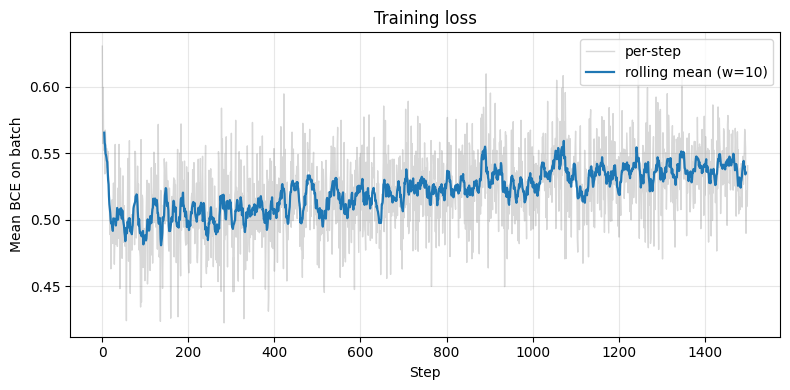

In [10]:
_ = viz.plot_training_loss(result.history.train_loss, FIGS_DIR / 'training_loss.png', window=10)

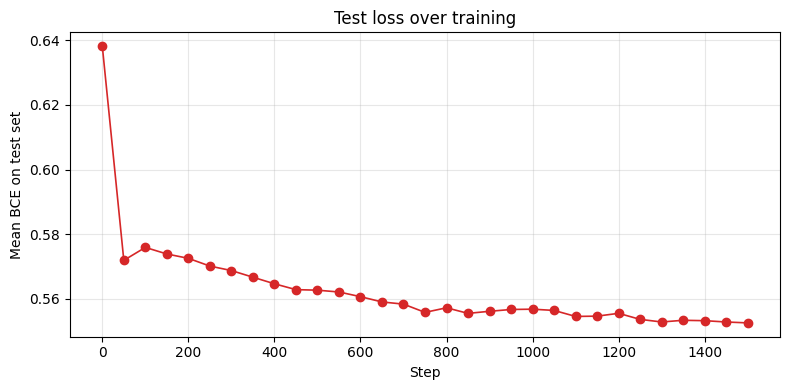

In [11]:
_ = viz.plot_test_loss(result.history.test_loss_steps, result.history.test_loss, FIGS_DIR / 'test_loss.png')

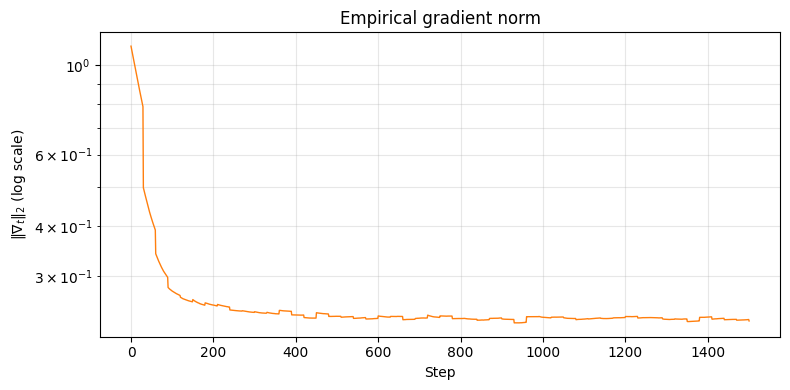

In [12]:
_ = viz.plot_gradient_norm(result.history.grad_norm, FIGS_DIR / 'gradient_norm.png')

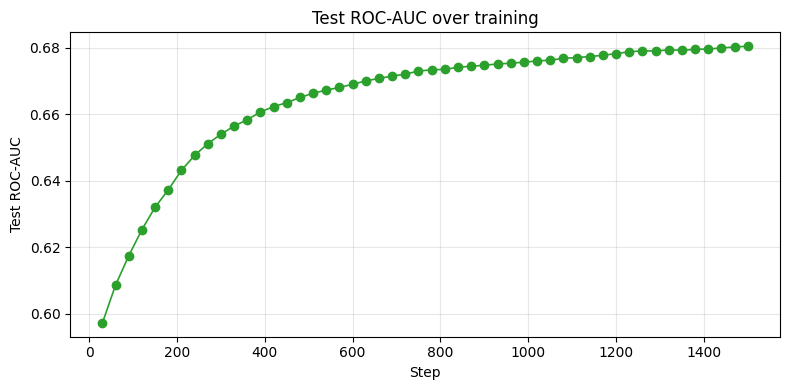

In [13]:
_ = viz.plot_auc_history(result.history.eval_steps, result.history.eval_auc, FIGS_DIR / 'auc_history.png')

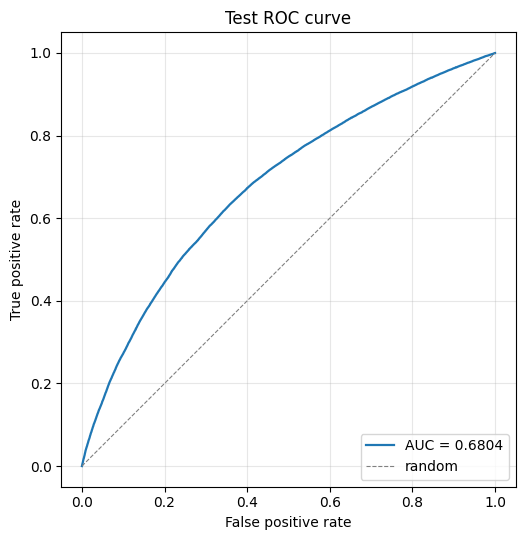

In [14]:
logits = np.asarray(model_mod.forward(result.params_final, data.x_test))
_ = viz.plot_roc_curve(np.asarray(data.y_test), logits, auc_final, FIGS_DIR / 'roc_curve.png')

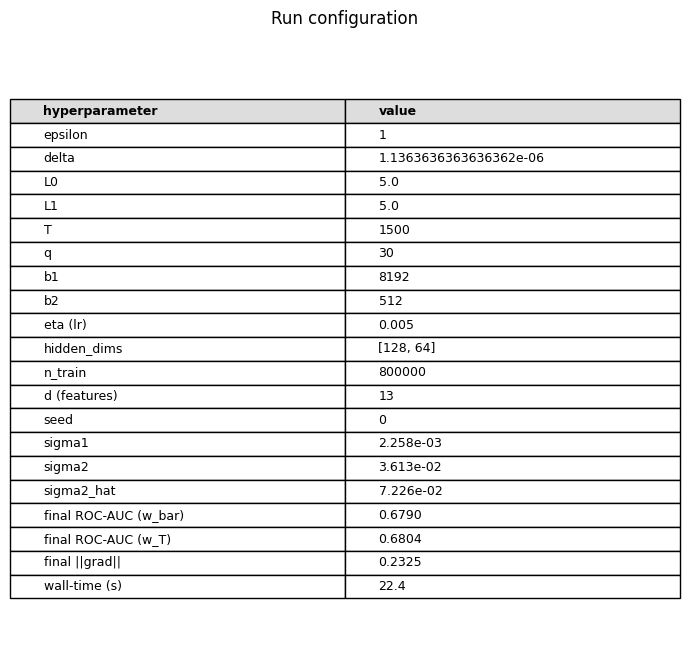

In [15]:
summary = {
    'epsilon': config.epsilon, 'delta': config.delta,
    'L0': config.L0, 'L1': config.L1,
    'T': config.T, 'q': config.q, 'b1': config.b1, 'b2': config.b2,
    'eta (lr)': config.eta, 'hidden_dims': list(config.hidden_dims),
    'n_train': n_train, 'd (features)': d, 'seed': config.seed,
    'sigma1': f'{noise.sigma1:.3e}',
    'sigma2': f'{noise.sigma2:.3e}',
    'sigma2_hat': f'{noise.sigma2_hat:.3e}',
    'final ROC-AUC (w_bar)': f'{auc_random:.4f}',
    'final ROC-AUC (w_T)': f'{auc_final:.4f}',
    'final ||grad||': f'{result.history.grad_norm[-1]:.4f}',
    'wall-time (s)': f'{result.history.wall_time_s:.1f}',
}
_ = viz.plot_hyperparameter_summary(summary, FIGS_DIR / 'hyperparameters.png')

## 6. Final summary

In [16]:
print('===== Private SpiderBoost on Criteo (numerical features) =====')
print(f'Privacy budget: ε={config.epsilon}, δ={config.delta}')
print(f'Architecture:   MLP {[d, *config.hidden_dims, 1]} (LayerNorm + ReLU)')
print(f'T={config.T} steps, q={config.q} per phase, b1={config.b1}, b2={config.b2}, η={config.eta}')
print()
print(f'Final test ROC-AUC (w_bar, random iterate per Algorithm 2): {auc_random:.4f}')
print(f'Final test ROC-AUC (w_T, last iterate):                     {auc_final:.4f}')
print(f'Final empirical gradient norm ||grad_T||:                   {result.history.grad_norm[-1]:.4f}')

===== Private SpiderBoost on Criteo (numerical features) =====
Privacy budget: ε=1, δ=1.1363636363636362e-06
Architecture:   MLP [13, 128, 64, 1] (LayerNorm + ReLU)
T=1500 steps, q=30 per phase, b1=8192, b2=512, η=0.005

Final test ROC-AUC (w_bar, random iterate per Algorithm 2): 0.6790
Final test ROC-AUC (w_T, last iterate):                     0.6804
Final empirical gradient norm ||grad_T||:                   0.2325


In [17]:
data = load_dataset("criteo_1M", data_dir=DATA_PATH.parent, test_fraction=0.2, seed=config.seed)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')
print(f'positive rate (train): {float(data.y_train.mean()):.4f}')
print(f'positive rate (test):  {float(data.y_test.mean()):.4f}')

train: (800000, 13)   test: (200000, 13)
positive rate (train): 0.2510
positive rate (test):  0.2520
